In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
import math
from scipy.optimize import curve_fit
from scipy.special import erf
import re
from scipy.stats import norm
from mpl_toolkits.mplot3d import Axes3D
from pathlib import Path

In [2]:
# (垂直方向, 平行方向) = (up, left), (down, right)のペアにしてください
filepath_ver = '/Users/taisei/Desktop/ナイフエッジ関係/20260113_horizontal_3mm_band3/power_sweep_data_20260113_192400_hori_left_3mm_2.csv'
filepath_hori = '/Users/taisei/Desktop/ナイフエッジ関係/20260113_horizontal_3mm_band3/power_sweep_data_20260113_192718_hori_right_3mm_2.csv'

In [3]:
re_basename_ver = os.path.splitext(os.path.basename(filepath_ver))[0]
re_basename_hori = os.path.splitext(os.path.basename(filepath_hori))[0]
basename_ver_pre = re_basename_ver.replace(' ', '')
basename_hori_pre = re_basename_hori.replace(' ', '')
basename_ver = basename_ver_pre.replace('power_sweep_data_', '')
basename_hori = basename_hori_pre.replace('power_sweep_data_', '')

print(re_basename_ver)
print(basename_ver_pre)
print(basename_ver)
print(re_basename_hori)
print(basename_hori_pre)
print(basename_hori)

power_sweep_data_20260113_192400_hori_left_3mm_2
power_sweep_data_20260113_192400_hori_left_3mm_2
20260113_192400_hori_left_3mm_2
power_sweep_data_20260113_192718_hori_right_3mm_2
power_sweep_data_20260113_192718_hori_right_3mm_2
20260113_192718_hori_right_3mm_2


In [4]:
df_ver = pd.read_csv(filepath_ver, names = ['position', 'power'], skiprows = 1)
df_hori = pd.read_csv(filepath_hori, names = ['position', 'power'], skiprows = 1)
print(pd.concat([df_ver, df_hori], axis = 1))

    position   power  position   power
0      150.0 -22.514     150.0 -18.575
1      300.0 -22.520     300.0 -18.547
2      450.0 -22.527     450.0 -18.522
3      600.0 -22.521     600.0 -18.525
4      750.0 -22.536     750.0 -18.523
5      900.0 -22.547     900.0 -18.457
6     1050.0 -22.532    1050.0 -18.502
7     1200.0 -22.518    1200.0 -18.455
8     1350.0 -22.516    1350.0 -18.492
9     1500.0 -22.523    1500.0 -18.586
10    1650.0 -22.515    1650.0 -18.593
11    1800.0 -22.495    1800.0 -18.649
12    1950.0 -22.491    1950.0 -18.742
13    2100.0 -22.485    2100.0 -18.709
14    2250.0 -22.451    2250.0 -18.817
15    2400.0 -22.388    2400.0 -19.033
16    2550.0 -22.280    2550.0 -19.387
17    2700.0 -22.064    2700.0 -19.821
18    2850.0 -21.615    2850.0 -20.258
19    3000.0 -20.966    3000.0 -20.695
20    3150.0 -20.455    3150.0 -21.307
21    3300.0 -19.993    3300.0 -21.858
22    3450.0 -19.534    3450.0 -22.166
23    3600.0 -19.122    3600.0 -22.357
24    3750.0 -18.851    3

In [5]:
position_ver = np.array(df_ver['position'])
position_hori = np.array(df_hori['position'])
posi_ver = position_ver*0.02
posi_hori = position_hori*0.02

if 'up' in basename_ver:
    posi_ver = posi_ver[::-1]
    print(posi_ver)
else:
    posi_ver = posi_ver
    print(posi_ver)

if 'left' in basename_hori:
    posi_hori = posi_hori[::-1]
    print(posi_hori)
else:
    posi_hori = posi_hori
    print(posi_hori)

[  3.   6.   9.  12.  15.  18.  21.  24.  27.  30.  33.  36.  39.  42.
  45.  48.  51.  54.  57.  60.  63.  66.  69.  72.  75.  78.  81.  84.
  87.  90.  93.  96.  99. 102. 105. 108. 111. 114. 117. 120.]
[  3.   6.   9.  12.  15.  18.  21.  24.  27.  30.  33.  36.  39.  42.
  45.  48.  51.  54.  57.  60.  63.  66.  69.  72.  75.  78.  81.  84.
  87.  90.  93.  96.  99. 102. 105. 108. 111. 114. 117. 120.]


In [6]:
power_dBm_ver = np.array(df_ver['power'])
power_dBm_hori = np.array(df_hori['power'])

In [7]:
# dBmをリニア(mW)に変換
power_ver = 10**(power_dBm_ver/10)
power_hori = 10**(power_dBm_hori/10)

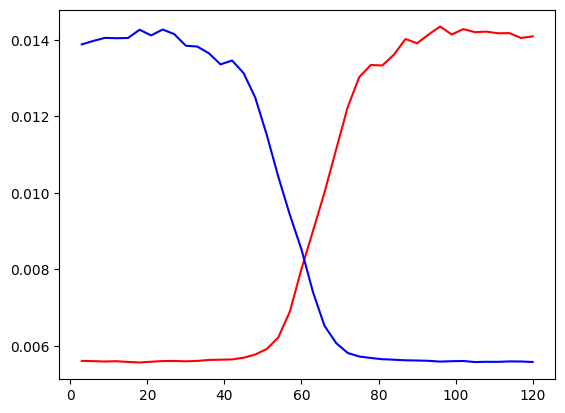

In [8]:
plt.plot(posi_ver, power_ver, color = 'red')
plt.plot(posi_hori, power_hori, color = 'blue')

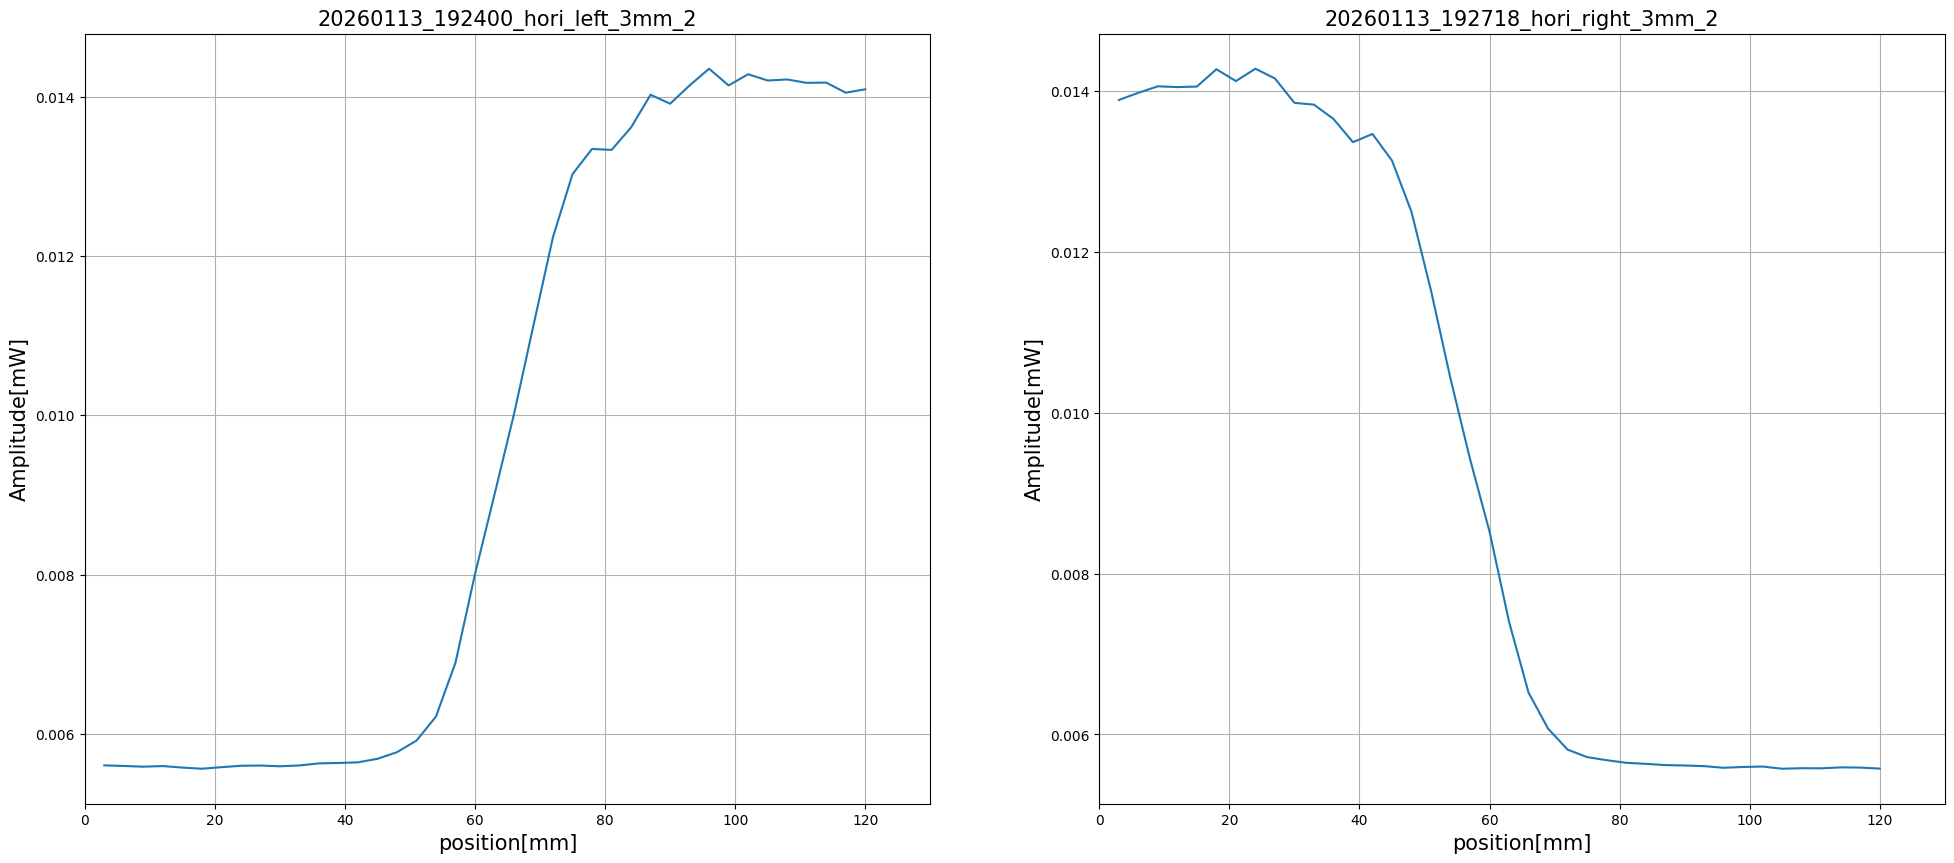

In [9]:
# plt.rcParams['font.size'] = 20
# plt.rcParams['font.family'] = 'Times New Roman'
fig, ax = plt.subplots(1, 2, figsize = (24, 10))

#　垂直方向のグラフを表示
ax[0].set_xlabel('position[mm]', fontsize = 15)
ax[0].set_ylabel('Amplitude[mW]', fontsize = 15)
ax[0].set_title(basename_ver, fontsize = 15)
# ax[0].set_aspect('equal') # スケールを揃える
ax[0].grid()
ax[0].set_xlim(0, 130)
# ax[0].set_ylim(0.000, 0.040)
ax[0].plot(posi_ver, power_ver)
# if 'up' in basename_ver:
    # ax[0].invert_xaxis()

#　平行方向のグラフを表示
ax[1].set_xlabel('position[mm]', fontsize = 15)
ax[1].set_ylabel('Amplitude[mW]', fontsize = 15)
ax[1].set_title(basename_hori, fontsize = 15)
# ax[1].set_aspect('equal') # スケールを揃える
ax[1].grid()
ax[1].set_xlim(0, 130)
# ax[1].set_ylim(0.000, 0.040)
ax[1].plot(posi_hori, power_hori)
# if 'left' in basename_hori:
    # ax[1].invert_xaxis()

# フィッティング

In [10]:
pi = np.pi

In [11]:
sampling_points = 1000

In [12]:
def quadratic_func(x, a, b, c, d):
    return -(pi*(a**2)/4)*((1+(erf((x-b)/a)))*c)+d

In [13]:
# --- 3. curve_fit を使ってフィッティングを実行 ---
# poptには最適化されたパラメータ[a, b, c]が格納されます
initial_params_ver = [40, 60, 0.01, 0.01] # 警告に表示されたpopt値に近しい値を設定してみる
initial_params_hori = [40, 60, 0.01, 0.01] # 警告に表示されたpopt値に近しい値を設定してみる

# 最適化された推定値(popt)と共分散(pcov)の計算
popt_ver, pcov_ver = curve_fit(quadratic_func, posi_ver, power_ver, p0 = initial_params_ver)
popt_hori, pcov_hori = curve_fit(quadratic_func, posi_hori, power_hori, p0 = initial_params_hori)

# 最適化されたパラメータを画面に表示
print(f"フィッティングによって得られたパラメータ(垂直方向) (a, b, c): {popt_ver}")
# print(f"a = {popt_ver[0]:.3f}, b = {popt_ver[1]:.3f}, c = {popt_ver[2]:.3f}")
print('error =', np.sqrt(np.diag(pcov_ver)))

print(f"フィッティングによって得られたパラメータ(平行方向) (a, b, c): {popt_hori}")
# print(f"a = {popt_hori[0]:.3f}, b = {popt_hori[1]:.3f}, c = {popt_hori[2]:.3f}")
print('error =', np.sqrt(np.diag(pcov_hori)))

フィッティングによって得られたパラメータ(垂直方向) (a, b, c): [ 1.26082499e+01  6.55122857e+01 -3.41509047e-05  5.58111823e-03]
error = [3.29691511e-01 1.71684123e-01 1.70485708e-06 3.29415904e-05]
フィッティングによって得られたパラメータ(平行方向) (a, b, c): [1.27922819e+01 5.58847029e+01 3.27739238e-05 1.40081668e-02]
error = [3.29139608e-01 1.71513276e-01 1.60790338e-06 3.62850769e-05]


In [14]:
# --- 4. 近似曲線用のデータを生成 ---
# 元のx軸データよりも細かい点を生成し、滑らかな曲線を描画する
x_fit_ver = np.linspace(posi_ver.min(), posi_ver.max(), sampling_points)
x_fit_hori = np.linspace(posi_hori.min(), posi_hori.max(), sampling_points)
# 求めたパラメータpoptを使って、対応するy軸の値を計算
# *poptは、配列poptの要素をアンパックしてa, b, cとして関数に渡す記法
y_fit_ver = quadratic_func(x_fit_ver, *popt_ver)
y_fit_hori = quadratic_func(x_fit_hori, *popt_hori)

(0.0, 120.0)

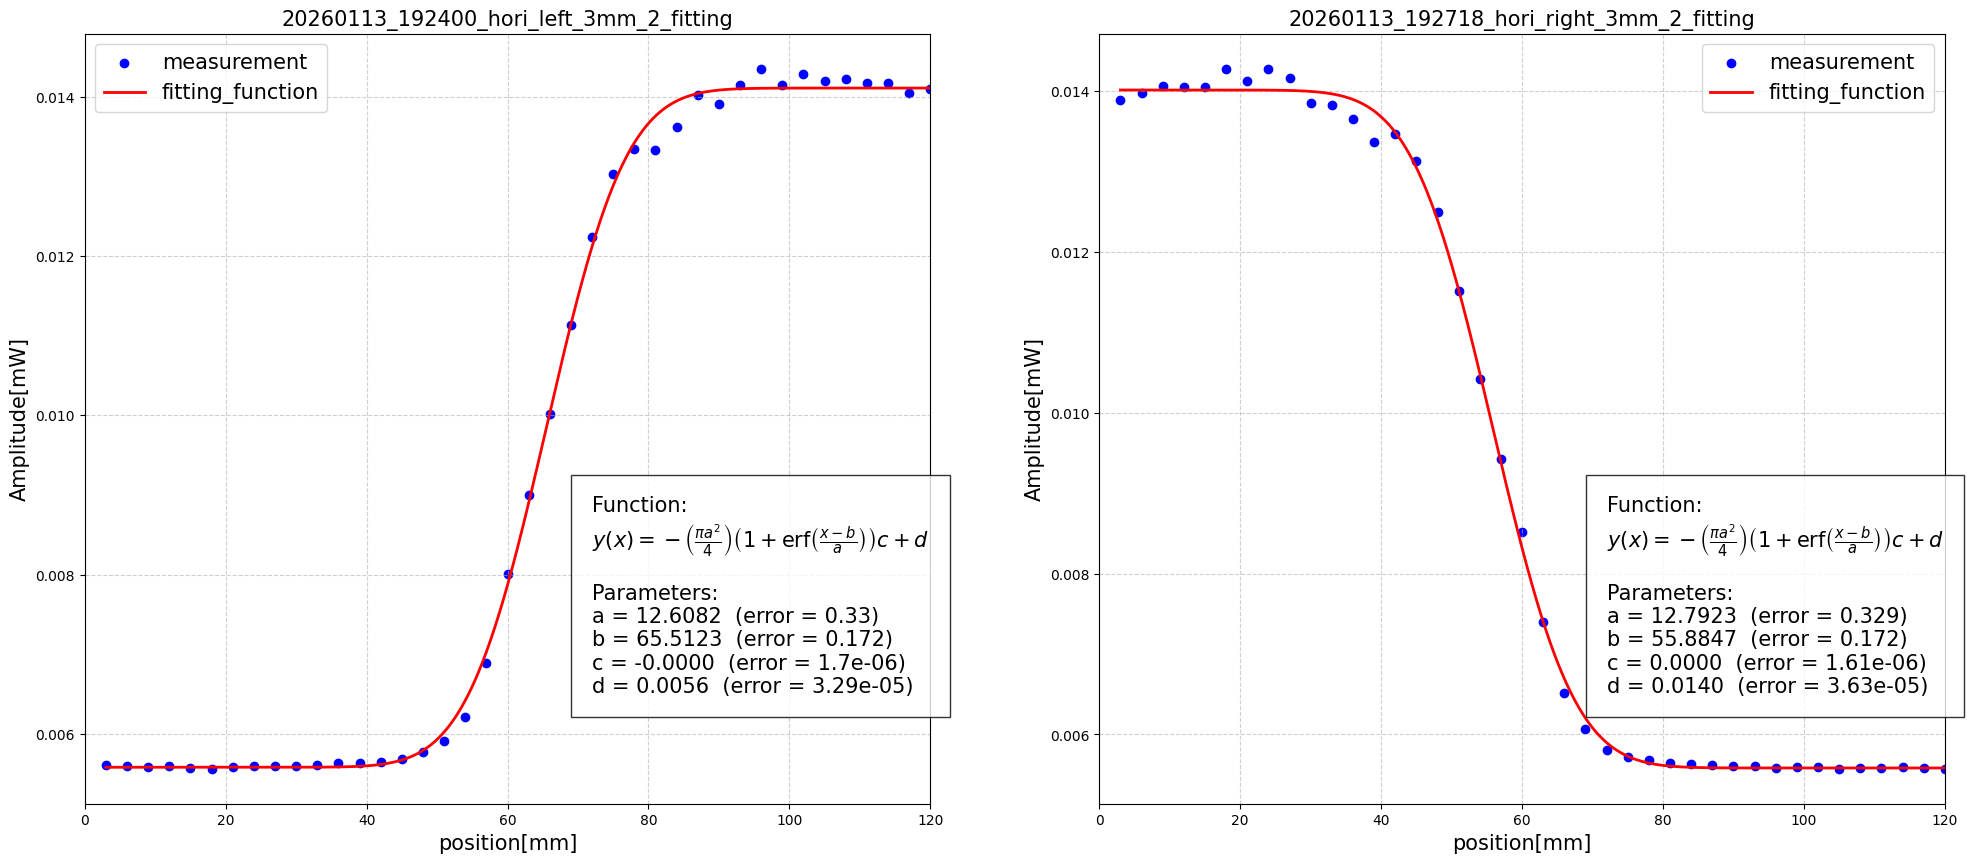

In [15]:
# --- 5. グラフを描画 ---
# グラフのサイズを指定
# plt.figure(figsize = (10, 6))
fig, ax = plt.subplots(1, 2, figsize = (24, 10))

# 元のデータ点を青い点でプロット(散布図)
# plt.scatter(posi, power, label = 'measurement', color = 'blue')
ax[0].scatter(posi_ver, power_ver, label = 'measurement', color = 'blue')
ax[1].scatter(posi_hori, power_hori, label = 'measurement', color = 'blue')

# フィットした曲線を赤い線でプロット
# plt.plot(x_fit, y_fit, label = 'fitting_function', color = 'red', linewidth = 2)
ax[0].plot(x_fit_ver, y_fit_ver, label = 'fitting_function', color = 'red', linewidth = 2)
ax[1].plot(x_fit_hori, y_fit_hori, label = 'fitting_function', color = 'red', linewidth = 2)

# グラフのタイトルやラベルを設定
# plt.title(basename + '_fitting', fontsize = 20)
# plt.xlabel('position[mm]', fontsize = 20)
# plt.ylabel('Amplitude[mW]', fontsize = 20)
ax[0].set_title(basename_ver + '_fitting', fontsize = 15)
ax[0].set_xlabel('position[mm]', fontsize = 15)
ax[0].set_ylabel('Amplitude[mW]', fontsize = 15)

ax[1].set_title(basename_hori + '_fitting', fontsize = 15)
ax[1].set_xlabel('position[mm]', fontsize = 15)
ax[1].set_ylabel('Amplitude[mW]', fontsize = 15)

# 凡例を表示
# plt.legend(fontsize = 15)
ax[0].legend(fontsize = 15)
ax[1].legend(fontsize = 15)

# グリッド線を表示
# plt.grid(True, linestyle = '--', alpha = 0.6)
ax[0].grid(True, linestyle = '--', alpha = 0.6)
ax[1].grid(True, linestyle = '--', alpha = 0.6)

formula_latex = r"$y(x) = -\left( \frac{\pi a^2}{4} \right) \left( 1 + \text{erf}\left(\frac{x-b}{a}\right) \right) c + d$"

param_text_ver = (
    f"a = {popt_ver[0]:.4f}  (error = {np.sqrt(np.diag(pcov_ver))[0]:.3})\n"
    f"b = {popt_ver[1]:.4f}  (error = {np.sqrt(np.diag(pcov_ver))[1]:.3})\n"
    f"c = {popt_ver[2]:.4f}  (error = {np.sqrt(np.diag(pcov_ver))[2]:.3})\n"
    f"d = {popt_ver[3]:.4f}  (error = {np.sqrt(np.diag(pcov_ver))[3]:.3})"
)
param_text_hori = (
    f"a = {popt_hori[0]:.4f}  (error = {np.sqrt(np.diag(pcov_hori))[0]:.3})\n"
    f"b = {popt_hori[1]:.4f}  (error = {np.sqrt(np.diag(pcov_hori))[1]:.3})\n"
    f"c = {popt_hori[2]:.4f}  (error = {np.sqrt(np.diag(pcov_hori))[2]:.3})\n"
    f"d = {popt_hori[3]:.4f}  (error = {np.sqrt(np.diag(pcov_hori))[3]:.3})"
)

text_box_ver = f"Function:\n{formula_latex}\n\nParameters:\n{param_text_ver}"
text_box_hori = f"Function:\n{formula_latex}\n\nParameters:\n{param_text_hori}"

# グラフ上の任意の位置にテキストボックスを配置
# transform = ax.transAxesは、座標がグラフの左下(0, 0)から右上(1, 1)の相対座標であることを示す
# bboxはテキストを囲むボックスのスタイル設定
ax[0].text(
    0.6, # X座標(グラフの右端を1.0とする)
    0.4, # Y座標(グラフの上端を1.0とする)
    text_box_ver,
    transform = ax[0].transAxes,
    fontsize = 15,
    verticalalignment = 'top',
    bbox = dict(boxstyle = 'square,pad = 1', facecolor = 'white', alpha = 0.8),
)

ax[1].text(
    0.6, # X座標(グラフの右端を1.0とする)
    0.4, # Y座標(グラフの上端を1.0とする)
    text_box_hori,
    transform = ax[1].transAxes,
    fontsize = 15,
    verticalalignment = 'top',
    bbox = dict(boxstyle = 'square,pad = 1', facecolor = 'white', alpha = 0.8),
)

# plt.xlim([0.00, 120.00])
# plt.ylim([0.005, 0.030])
ax[0].set_xlim([0.00, 120.00])
# ax[0].set_ylim([0.00, 0.040])
ax[1].set_xlim([0.00, 120.00])
# ax[1].set_ylim([0.00, 0.040])

# plt.savefig(f'{basename_ver}+{basename_hori}_knife_edge_fitting.pdf', bbox_inches = 'tight', format = 'pdf', dpi = 100)

In [16]:
# y_fit[1:]

In [17]:
# x_fit

In [18]:
# 微分の定義
y_dif_list_ver = []
for i in range(sampling_points-1):
    y_dif_ver = (y_fit_ver[i+1]-y_fit_ver[i])/(x_fit_ver[i+1]-x_fit_ver[i])
    y_dif_list_ver.append(y_dif_ver)

y_dif_list_hori = []
for i in range(sampling_points-1):
    y_dif_hori = (y_fit_hori[i+1]-y_fit_hori[i])/(x_fit_hori[i+1]-x_fit_hori[i])
    y_dif_list_hori.append(y_dif_hori)

In [19]:
print(len(y_dif_list_ver), len(y_dif_list_hori))

999 999


In [20]:
x_fit_ver_2 = np.linspace(posi_ver.min(), posi_ver.max(), sampling_points-1)
x_fit_hori_2 = np.linspace(posi_hori.min(), posi_hori.max(), sampling_points-1)

(0.0, 120.0)

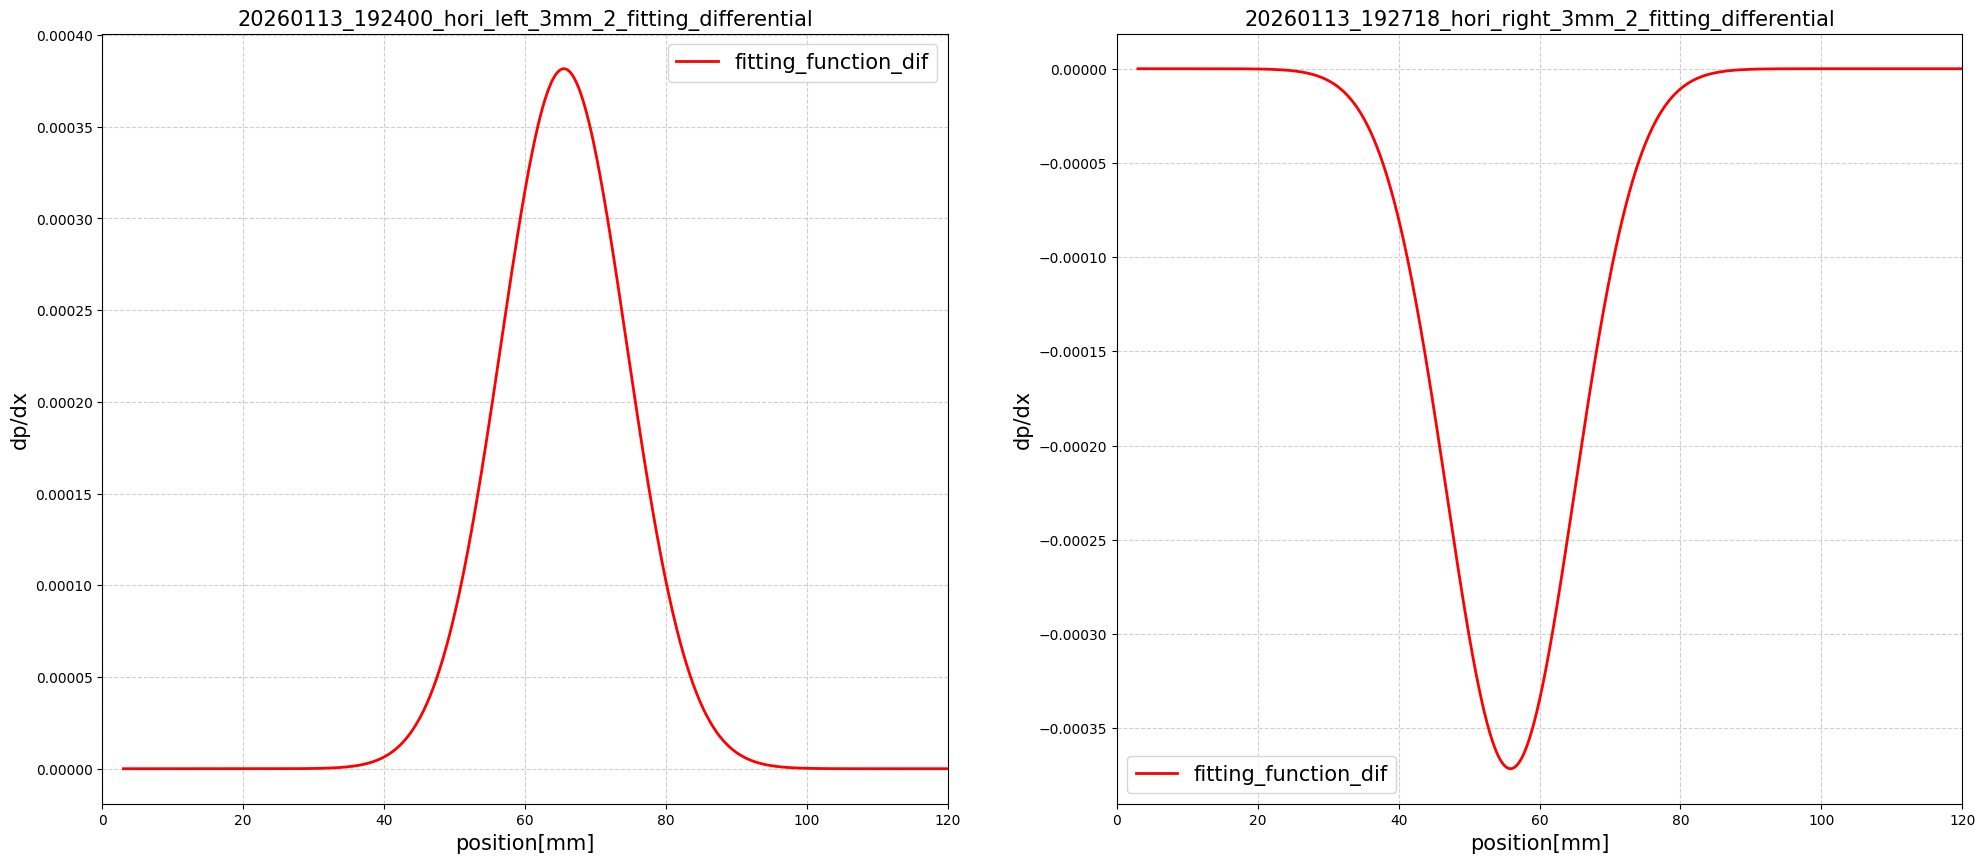

In [21]:
# --- 5. グラフを描画 ---
# グラフのサイズを指定
# plt.figure(figsize = (10, 6))
fig, ax = plt.subplots(1, 2, figsize = (24, 10))

# 元のデータ点を青い点でプロット(散布図)
# plt.scatter(posi, power, label = 'measurement', color = 'blue')
# ax[0].scatter(posi_ver, power_ver, label = 'measurement', color = 'blue')
# ax[1].scatter(posi_hori, power_hori, label = 'measurement', color = 'blue')

# フィットした曲線を赤い線でプロット
# plt.plot(x_fit_, y_dif_list, label = 'fitting_function_dif', color = 'red', linewidth = 2)
ax[0].plot(x_fit_ver_2, y_dif_list_ver, label = 'fitting_function_dif', color = 'red', linewidth = 2)
ax[1].plot(x_fit_hori_2, y_dif_list_hori, label = 'fitting_function_dif', color = 'red', linewidth = 2)

# グラフのタイトルやラベルを設定
# plt.title(basename + '_fitting_differential', fontsize = 20)
# plt.xlabel('position[mm]', fontsize = 20)
# plt.ylabel('dp/dx', fontsize = 20)
ax[0].set_title(basename_ver + '_fitting_differential', fontsize = 15)
ax[0].set_xlabel('position[mm]', fontsize = 15)
ax[0].set_ylabel('dp/dx', fontsize = 15)
ax[1].set_title(basename_hori + '_fitting_differential', fontsize = 15)
ax[1].set_xlabel('position[mm]', fontsize = 15)
ax[1].set_ylabel('dp/dx', fontsize = 15)

# 凡例を表示
# plt.legend()
ax[0].legend(fontsize = 15)
ax[1].legend(fontsize = 15)

# グリッド線を表示
# plt.grid(True, linestyle = '--', alpha = 0.6)
ax[0].grid(True, linestyle = '--', alpha = 0.6)
ax[1].grid(True, linestyle = '--', alpha = 0.6)

# plt.xlim([0.00, 120.00])
# plt.ylim([-0.00075, 0.00075])
ax[0].set_xlim([0.00, 120.00])
# ax[0].set_ylim([-0.001, 0.001])
ax[1].set_xlim([0.00, 120.00])
# ax[1].set_ylim([-0.001, 0.001])

# plt.savefig(f'{basename_ver}+{basename_hori}_knife_edge_fitting_differential.pdf', bbox_inches = 'tight', format = 'pdf', dpi = 100)

In [22]:
def quadratic_func_gaus(x, a, b, c):
    return c*np.exp(-(((x-b)/a)**2)/2)

In [23]:
# --- 3. curve_fit を使ってフィッティングを実行 ---
# poptには最適化されたパラメータ[a, b, c]が格納されます
initial_params_ver_2 = [1, 80, 0.0001] # 警告に表示されたpopt値に近しい値を設定してみる
initial_params_hori_2 = [1, 80, 0.0001] # 警告に表示されたpopt値に近しい値を設定してみる

popt_ver_2, pcov_ver_2 = curve_fit(quadratic_func_gaus, x_fit_ver_2, y_dif_list_ver, p0 = initial_params_ver_2)
popt_hori_2, pcov_hori_2 = curve_fit(quadratic_func_gaus, x_fit_hori_2, y_dif_list_hori, p0 = initial_params_hori_2)

# 最適化されたパラメータを画面に表示
print(f"フィッティングによって得られたパラメータ(垂直方向) (a, b, c): {popt_ver_2}")
# print(f"a = {popt_ver_2[0]:.3f}, b = {popt_ver_2[1]:.3f}, c = {popt_ver_2[2]:.3f}")
print('error =', np.sqrt(np.diag(pcov_ver_2)))

# 最適化されたパラメータを画面に表示
print(f"フィッティングによって得られたパラメータ(平行方向) (a, b, c): {popt_hori_2}")
# print(f"a = {popt_hori_2[0]:.3f}, b = {popt_hori_2[1]:.3f}, c = {popt_hori_2[2]:.3f}")
print('error =', np.sqrt(np.diag(pcov_hori_2)))

フィッティングによって得られたパラメータ(垂直方向) (a, b, c): [8.92437644e+00 6.55163060e+01 3.81591630e-04]
error = [5.06452398e-12 5.06452402e-12 1.87538408e-16]
フィッティングによって得られたパラメータ(平行方向) (a, b, c): [ 9.05463615e+00  5.58790763e+01 -3.71550943e-04]
error = [4.84910520e-12 4.84910518e-12 1.72321553e-16]


In [24]:
# --- 4. 近似曲線用のデータを生成 ---
# 元のx軸データよりも細かい点を生成し、滑らかな曲線を描画する
x_fit_ver_3 = np.linspace(posi_ver.min(), posi_ver.max(), 999)
x_fit_hori_3 = np.linspace(posi_hori.min(), posi_hori.max(), 999)
# 求めたパラメータpoptを使って、対応するy軸の値を計算
# *poptは、配列poptの要素をアンパックしてa, b, cとして関数に渡す記法
y_fit_gaus_ver = quadratic_func_gaus(x_fit_ver_3, *popt_ver_2)
y_fit_gaus_hori = quadratic_func_gaus(x_fit_hori_3, *popt_hori_2)

(0.0, 120.0)

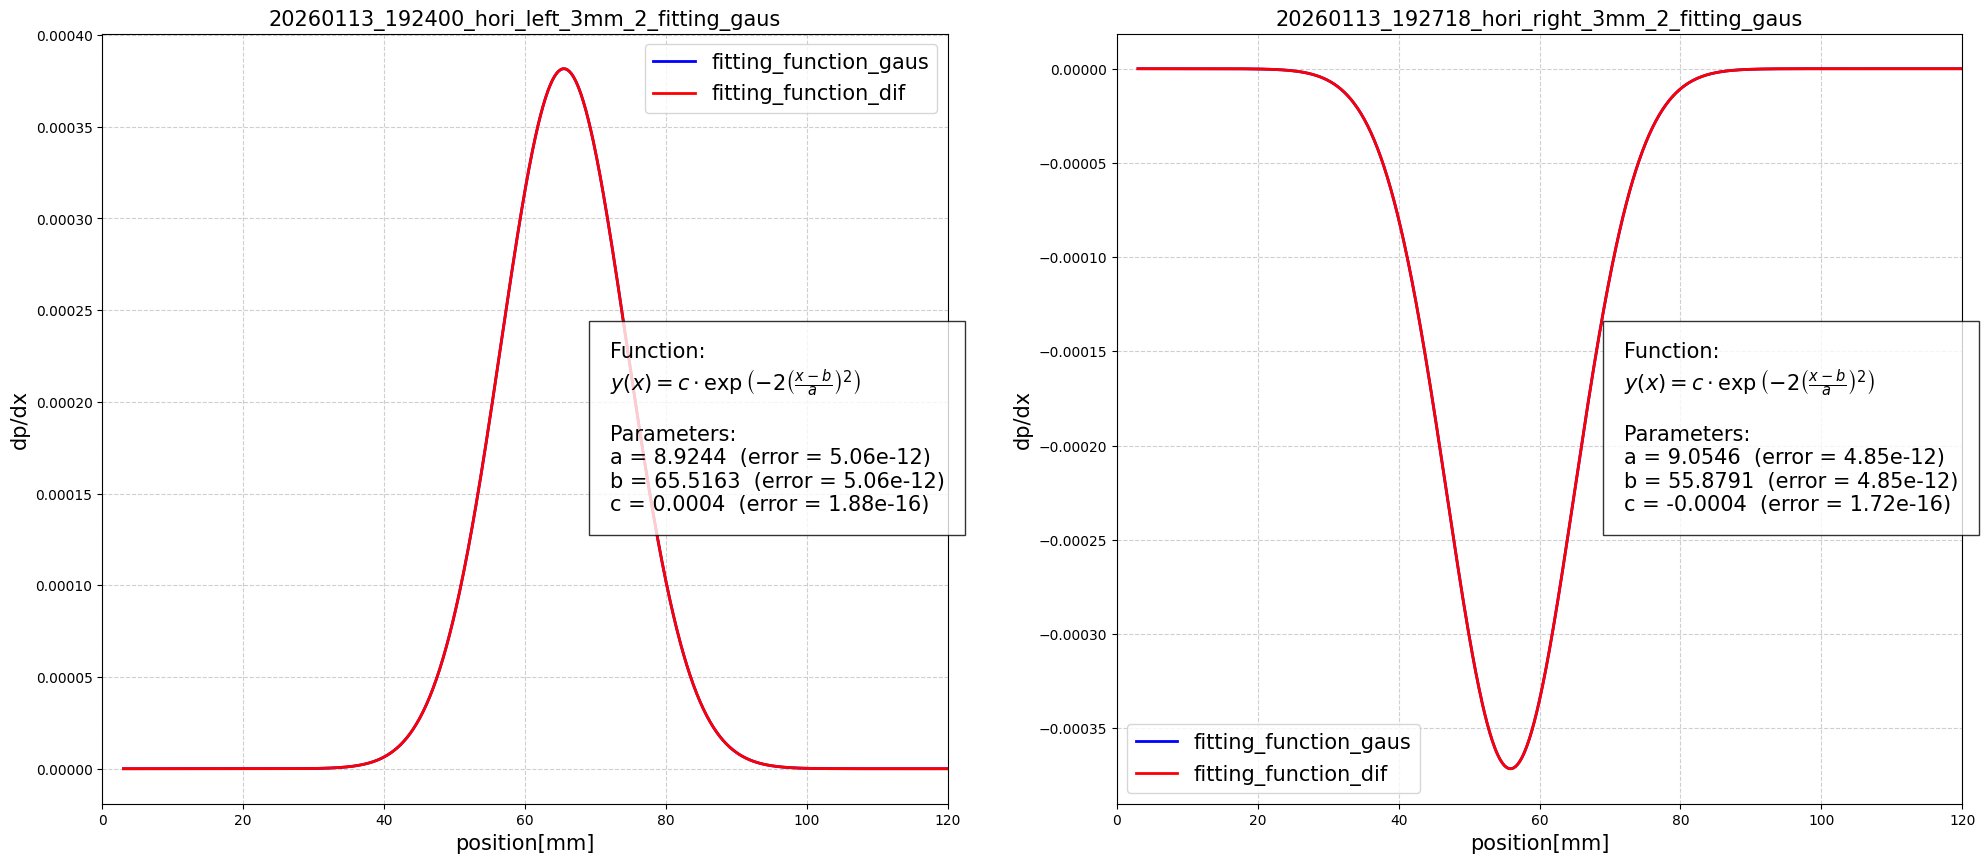

In [25]:
# --- 5. グラフを描画 ---
# グラフのサイズを指定
# plt.figure(figsize = (10, 6))
fig, ax = plt.subplots(1, 2, figsize = (24, 10))

# 元のデータ点を青い点でプロット(散布図)
# plt.scatter(posi, power, label = 'measurement', color = 'blue')
# ax[0].scatter(posi_ver, power_ver, label = 'measurement', color = 'blue')
# ax[1].scatter(posi_hori, power_hori, label = 'measurement', color = 'blue')

# フィットした曲線を赤い線でプロット
# plt.plot(x_fit, y_fit_gaus, label = 'fitting_function_gaus', color = 'blue', linewidth = 2)
# plt.plot(x_fit_, y_dif_list, label = 'fitting_function_dif', color = 'red', linewidth = 2)
ax[0].plot(x_fit_ver_3, y_fit_gaus_ver, label = 'fitting_function_gaus', color = 'blue', linewidth = 2)
ax[0].plot(x_fit_ver_3, y_dif_list_ver, label = 'fitting_function_dif', color = 'red', linewidth = 2)

ax[1].plot(x_fit_hori_3, y_fit_gaus_hori, label = 'fitting_function_gaus', color = 'blue', linewidth = 2)
ax[1].plot(x_fit_hori_3, y_dif_list_hori, label = 'fitting_function_dif', color = 'red', linewidth = 2)

# グラフのタイトルやラベルを設定
# plt.title(basename + '_fitting_gaus', fontsize = 20)
# plt.xlabel('position[mm]', fontsize = 20)
# plt.ylabel('dp/dx', fontsize = 20)
ax[0].set_title(basename_ver + '_fitting_gaus', fontsize = 15)
ax[0].set_xlabel('position[mm]', fontsize = 15)
ax[0].set_ylabel('dp/dx', fontsize = 15)

ax[1].set_title(basename_hori + '_fitting_gaus', fontsize = 15)
ax[1].set_xlabel('position[mm]', fontsize = 15)
ax[1].set_ylabel('dp/dx', fontsize = 15)

# 凡例を表示
# plt.legend()
ax[0].legend(fontsize = 15)
ax[1].legend(fontsize = 15)

# グリッド線を表示
# plt.grid(True, linestyle = '--', alpha = 0.6)
ax[0].grid(True, linestyle = '--', alpha = 0.6)
ax[1].grid(True, linestyle = '--', alpha = 0.6)

formula_latex = r"$y(x) = c \cdot \exp \left( -2 \left( \frac{x-b}{a} \right)^2 \right)$"

param_text_ver_2 = (
    f"a = {popt_ver_2[0]:.4f}  (error = {np.sqrt(np.diag(pcov_ver_2))[0]:.3})\n"
    f"b = {popt_ver_2[1]:.4f}  (error = {np.sqrt(np.diag(pcov_ver_2))[1]:.3})\n"
    f"c = {popt_ver_2[2]:.4f}  (error = {np.sqrt(np.diag(pcov_ver_2))[2]:.3})"
)

param_text_hori_2 = (
    f"a = {popt_hori_2[0]:.4f}  (error = {np.sqrt(np.diag(pcov_hori_2))[0]:.3})\n"
    f"b = {popt_hori_2[1]:.4f}  (error = {np.sqrt(np.diag(pcov_hori_2))[1]:.3})\n"
    f"c = {popt_hori_2[2]:.4f}  (error = {np.sqrt(np.diag(pcov_hori_2))[2]:.3})"
)

text_box_ver_2 = f"Function:\n{formula_latex}\n\nParameters:\n{param_text_ver_2}"
text_box_hori_2 = f"Function:\n{formula_latex}\n\nParameters:\n{param_text_hori_2}"

# グラフ上の任意の位置にテキストボックスを配置
# transform = ax.transAxesは、座標がグラフの左下(0, 0)から右上(1, 1)の相対座標であることを示す
# bboxはテキストを囲むボックスのスタイル設定
ax[0].text(
    0.6, # X座標(グラフの右端を1.0とする)
    0.6, # Y座標(グラフの上端を1.0とする)
    text_box_ver_2,
    transform = ax[0].transAxes,
    fontsize = 15,
    verticalalignment = 'top',
    bbox = dict(boxstyle = 'square,pad = 1', facecolor = 'white', alpha = 0.8)
)

ax[1].text(
    0.6, # X座標(グラフの右端を1.0とする)
    0.6, # Y座標(グラフの上端を1.0とする)
    text_box_hori_2,
    transform = ax[1].transAxes,
    fontsize = 15,
    verticalalignment = 'top',
    bbox = dict(boxstyle = 'square,pad = 1', facecolor = 'white', alpha = 0.8)
)

# plt.xlim([0.00, 120.00])
# plt.ylim([-0.00075, 0.00075])
ax[0].set_xlim([0.00, 120.00])
# ax[0].set_ylim([-0.001, 0.001])
ax[1].set_xlim([0.00, 120.00])
# ax[1].set_ylim([-0.001, 0.001])

# plt.savefig(f'{basename_ver}+{basename_hori}_knife_edge_fitting_gaus.pdf', bbox_inches = 'tight', format = 'pdf', dpi = 100)

#   2次元ガウス分布の生成
垂直方向のデータと平行方向のデータが独立した1次元ガウス分布として存在しているので、2次元の確率密度関数は各方向の確率密度関数の積で表される。したがって、各方向の平均(ave)と標準偏差(sigma)を求めてそれらを掛け合わせる。

[-57.         -55.82765531 -54.65531062 -53.48296593 -52.31062124
 -51.13827655 -49.96593186 -48.79358717 -47.62124248 -46.4488978
 -45.27655311 -44.10420842 -42.93186373 -41.75951904 -40.58717435
 -39.41482966 -38.24248497 -37.07014028 -35.89779559 -34.7254509
 -33.55310621 -32.38076152 -31.20841683 -30.03607214 -28.86372745
 -27.69138277 -26.51903808 -25.34669339 -24.1743487  -23.00200401
 -21.82965932 -20.65731463 -19.48496994 -18.31262525 -17.14028056
 -15.96793587 -14.79559118 -13.62324649 -12.4509018  -11.27855711
 -10.10621242  -8.93386774  -7.76152305  -6.58917836  -5.41683367
  -4.24448898  -3.07214429  -1.8997996   -0.72745491   0.44488978
   1.61723447   2.78957916   3.96192385   5.13426854   6.30661323
   7.47895792   8.65130261   9.82364729  10.99599198  12.16833667
  13.34068136  14.51302605  15.68537074  16.85771543  18.03006012
  19.20240481  20.3747495   21.54709419  22.71943888  23.89178357
  25.06412826  26.23647295  27.40881764  28.58116232  29.75350701
  30.9258517

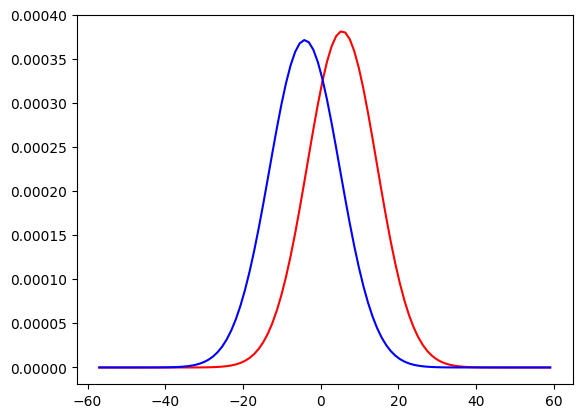

In [26]:
x_ver = (ax[0].get_lines()[0].get_xdata()[::10])-60
y_ver = np.abs(ax[0].get_lines()[0].get_ydata()[::10])
print(x_ver)
print(y_ver)

x_hori = (ax[1].get_lines()[1].get_xdata()[::10])-60
y_hori = np.abs(ax[1].get_lines()[1].get_ydata()[::10])
print(x_hori)
print(y_hori)

plt.plot(x_ver, y_ver, color = 'red')
plt.plot(x_hori, y_hori, color = 'blue')

In [27]:
# 平均(ave)と標準偏差(sigma)の計算
ave_y_ver, sigma_y_ver = norm.fit(y_ver)
ave_y_hori, sigma_y_hori = norm.fit(y_hori)
print(ave_y_ver, sigma_y_ver)
print(ave_y_hori, sigma_y_hori)

7.281340388052814e-05 0.00011977128139740744
7.193230606091735e-05 0.00011715051924694945


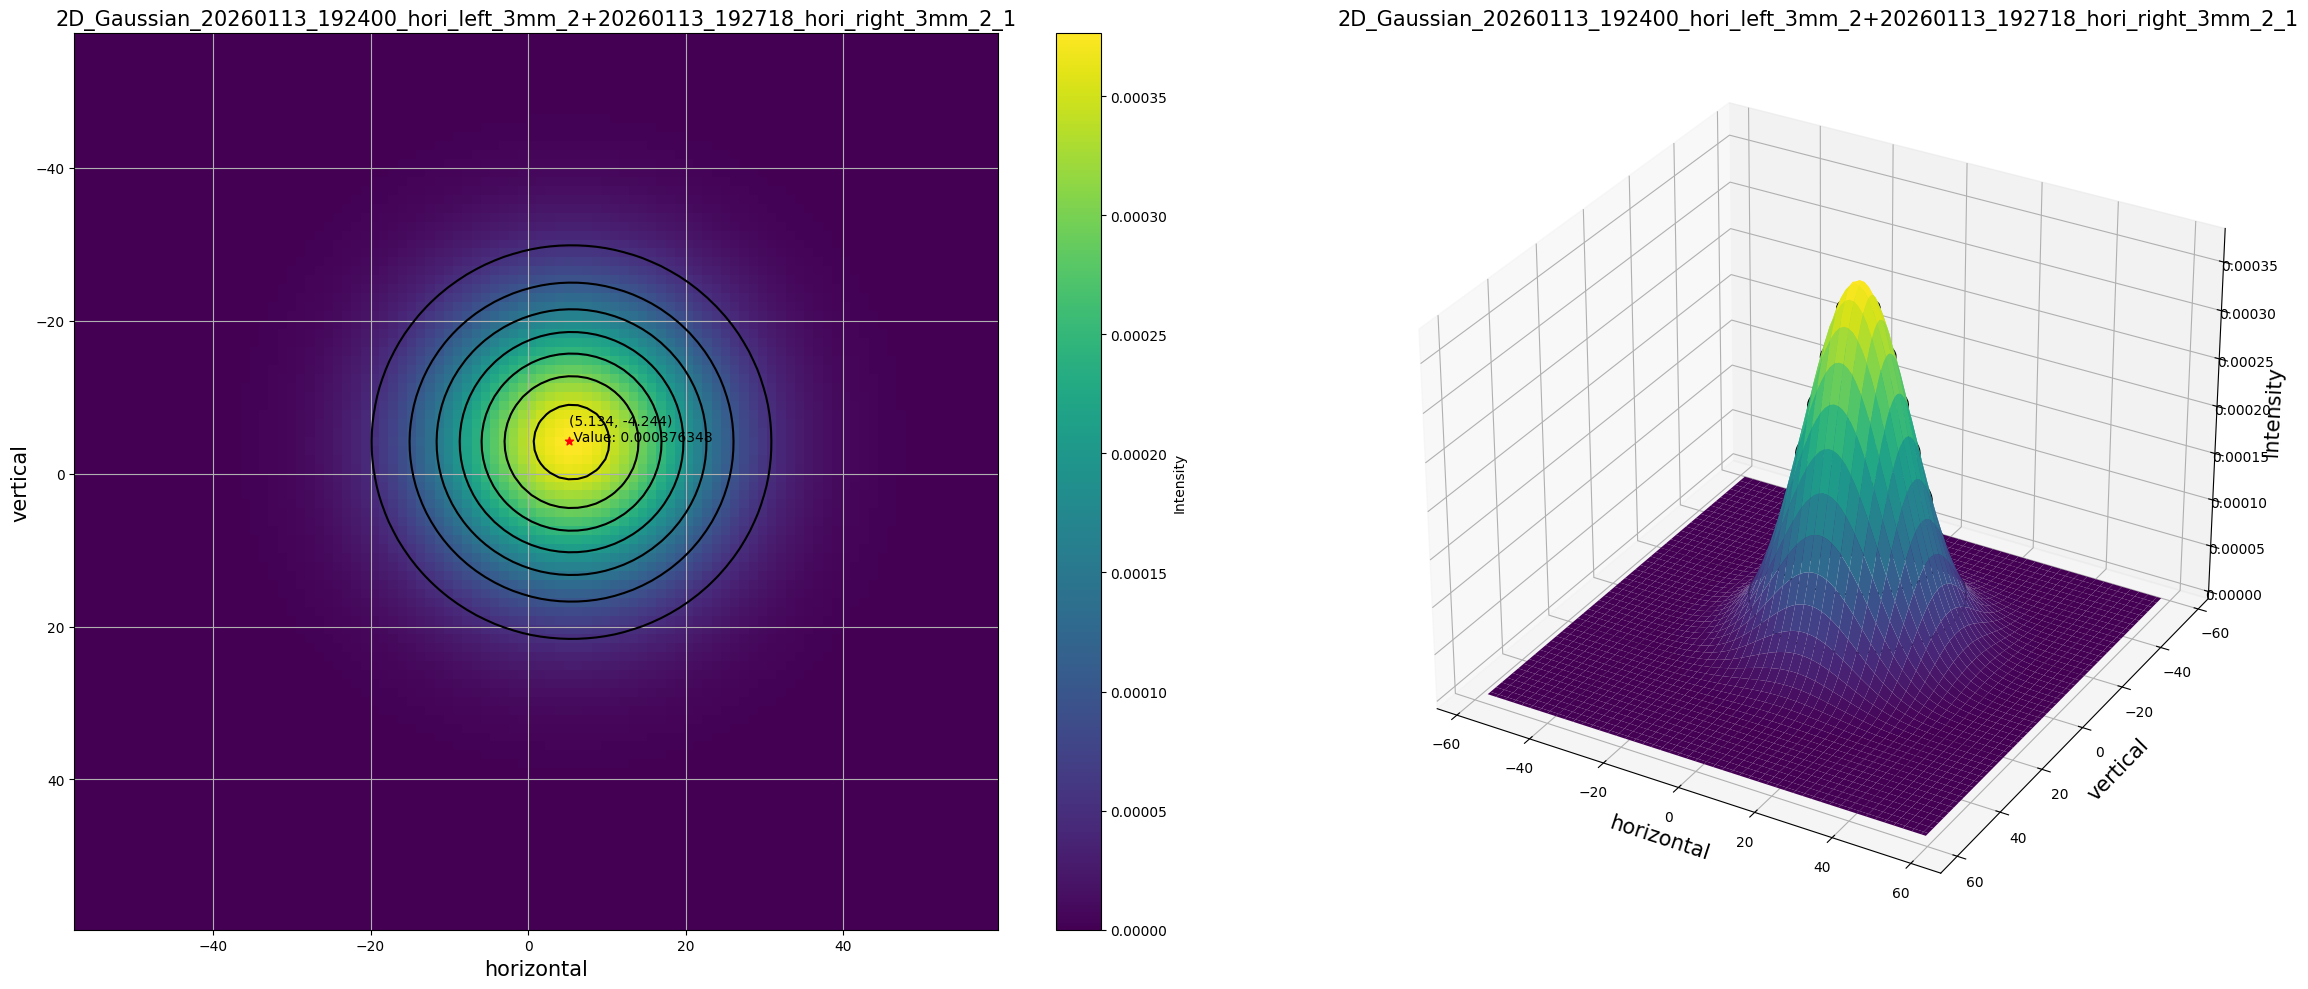

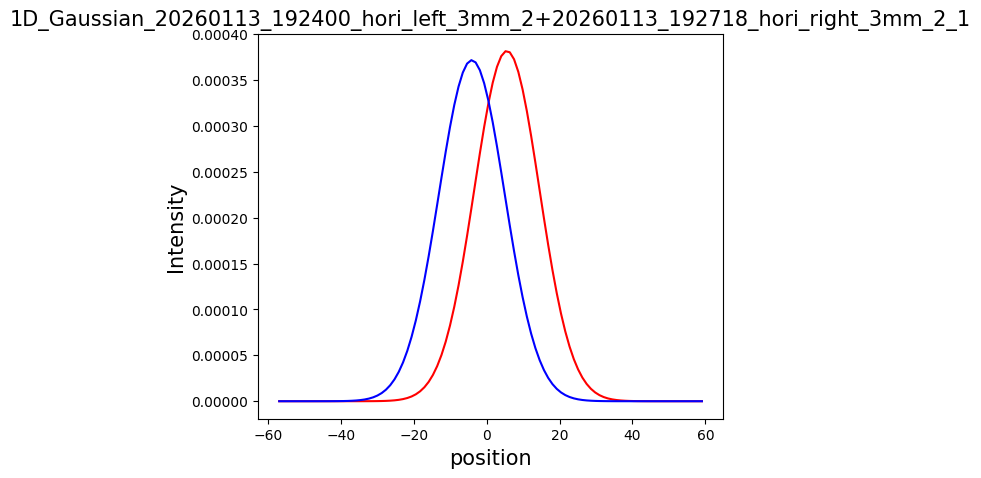

In [28]:
# np.outer(A, B)を使うことで、A[i]*B[j]の行列を作ることができる
Z = np.sqrt(np.outer(y_hori, y_ver))

fig = plt.figure(figsize = (24, 10))

ax0 = fig.add_subplot(1, 2, 1)
X, Y = np.meshgrid(x_hori, x_ver)
cp = ax0.pcolormesh(X, Y, Z, shading = 'auto', cmap = 'viridis')
fig.colorbar(cp, ax = ax0, label = 'Intensity')
plt.contour(X, Y, Z, colors = ['black'])
ax0.invert_yaxis()
ax0.grid(True)
ax0.set_title('2D_Gaussian_' + basename_ver + '+' + basename_hori + '_1', fontsize = 15)
ax0.set_xlabel('horizontal', fontsize = 15)
ax0.set_ylabel('vertical', fontsize = 15)

max_power = np.argmax(Z) # 最大値を見つける
r_power, c_power = np.unravel_index(max_power, Z.shape) #　行と列のインデックスに変換する
max_hori = X[r_power, c_power] # 最大値の座標を見つける
max_ver = Y[r_power, c_power] # 最大値の座標を見つける
max_value = Z[r_power, c_power] # 最大値を取得する
ax0.scatter(max_hori, max_ver, color = 'red', marker = '*') # 最大値の座標を表示する
ax0.text(max_hori, max_ver, f'({max_hori:.3f}, {max_ver:.3f})\n Value: {max_value:.9f}')

ax1 = fig.add_subplot(1, 2, 2, projection = '3d')
ax1.plot_surface(X, Y, Z, cmap = 'viridis')
plt.contour(X, Y, Z, colors = ['black'])
ax1.invert_yaxis()
ax1.grid(True)
ax1.set_title('2D_Gaussian_' + basename_ver + '+' + basename_hori + '_1', fontsize = 15)
ax1.set_xlabel('horizontal', fontsize = 15)
ax1.set_ylabel('vertical', fontsize = 15)
ax1.set_zlabel('Intensity', fontsize = 15)

# plt.savefig(f'{basename_ver}+{basename_hori}_2d_gaussian_1.pdf', bbox_inches = 'tight', format = 'pdf', dpi = 100)
plt.tight_layout()
plt.subplots_adjust(right = 1, wspace = 0.01)

fig = plt.figure(figsize = (6, 5))
ax = fig.add_subplot()
ax.plot(x_ver, y_ver, label = 'x_ver - y_ver', color = 'red')
ax.plot(x_hori, y_hori, label = 'x_hori - y_hori', color = 'blue')
ax.set_title('1D_Gaussian_' + basename_ver + '+' + basename_hori + '_1', fontsize = 15)
ax.set_xlabel('position', fontsize = 15)
ax.set_ylabel('Intensity', fontsize = 15)

plt.show()

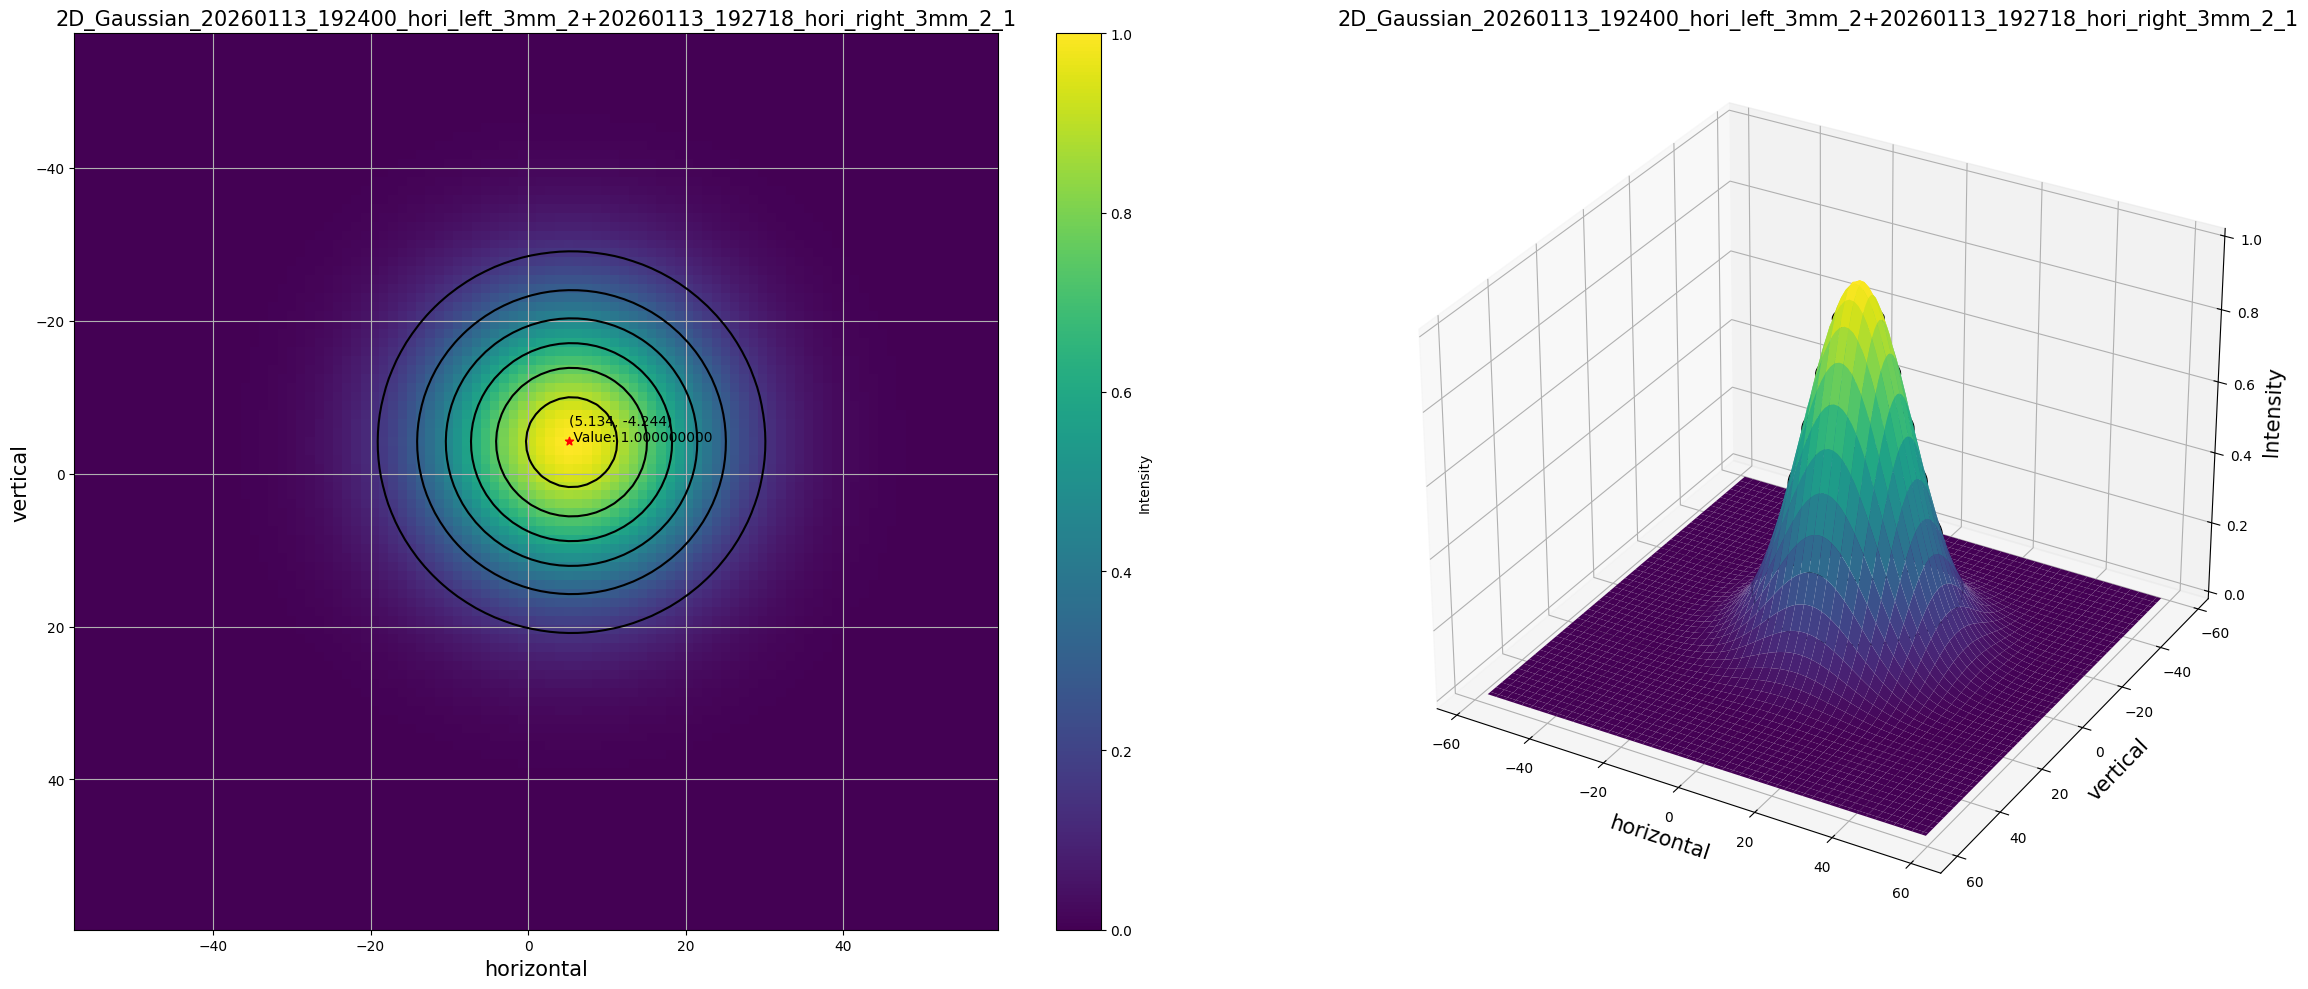

In [29]:
# np.outer(A, B)を使うことで、A[i]*B[j]の行列を作ることができる
Z_2 = Z/max_value

fig = plt.figure(figsize = (24, 10))

ax0 = fig.add_subplot(1, 2, 1)
X, Y = np.meshgrid(x_hori, x_ver)
cp = ax0.pcolormesh(X, Y, Z_2, shading = 'auto', cmap = 'viridis')
fig.colorbar(cp, ax = ax0, label = 'Intensity')
plt.contour(X, Y, Z_2, colors = ['black'])
ax0.invert_yaxis()
ax0.grid(True)
ax0.set_title('2D_Gaussian_' + basename_ver + '+' + basename_hori + '_1', fontsize = 15)
ax0.set_xlabel('horizontal', fontsize = 15)
ax0.set_ylabel('vertical', fontsize = 15)

max_power = np.argmax(Z_2) # 最大値を見つける
r_power, c_power = np.unravel_index(max_power, Z_2.shape) #　行と列のインデックスに変換する
max_hori = X[r_power, c_power] # 最大値の座標を見つける
max_ver = Y[r_power, c_power] # 最大値の座標を見つける
max_value = Z_2[r_power, c_power] # 最大値を取得する
ax0.scatter(max_hori, max_ver, color = 'red', marker = '*') # 最大値の座標を表示する
ax0.text(max_hori, max_ver, f'({max_hori:.3f}, {max_ver:.3f})\n Value: {max_value:.9f}')

ax1 = fig.add_subplot(1, 2, 2, projection = '3d')
ax1.plot_surface(X, Y, Z_2, cmap = 'viridis')
plt.contour(X, Y, Z_2, colors = ['black'])
ax1.invert_yaxis()
ax1.grid(True)
ax1.set_title('2D_Gaussian_' + basename_ver + '+' + basename_hori + '_1', fontsize = 15)
ax1.set_xlabel('horizontal', fontsize = 15)
ax1.set_ylabel('vertical', fontsize = 15)
ax1.set_zlabel('Intensity', fontsize = 15)

# plt.savefig(f'{basename_ver}+{basename_hori}_2d_gaussian_1.pdf', bbox_inches = 'tight', format = 'pdf', dpi = 100)
plt.tight_layout()
plt.subplots_adjust(right = 1, wspace = 0.01)

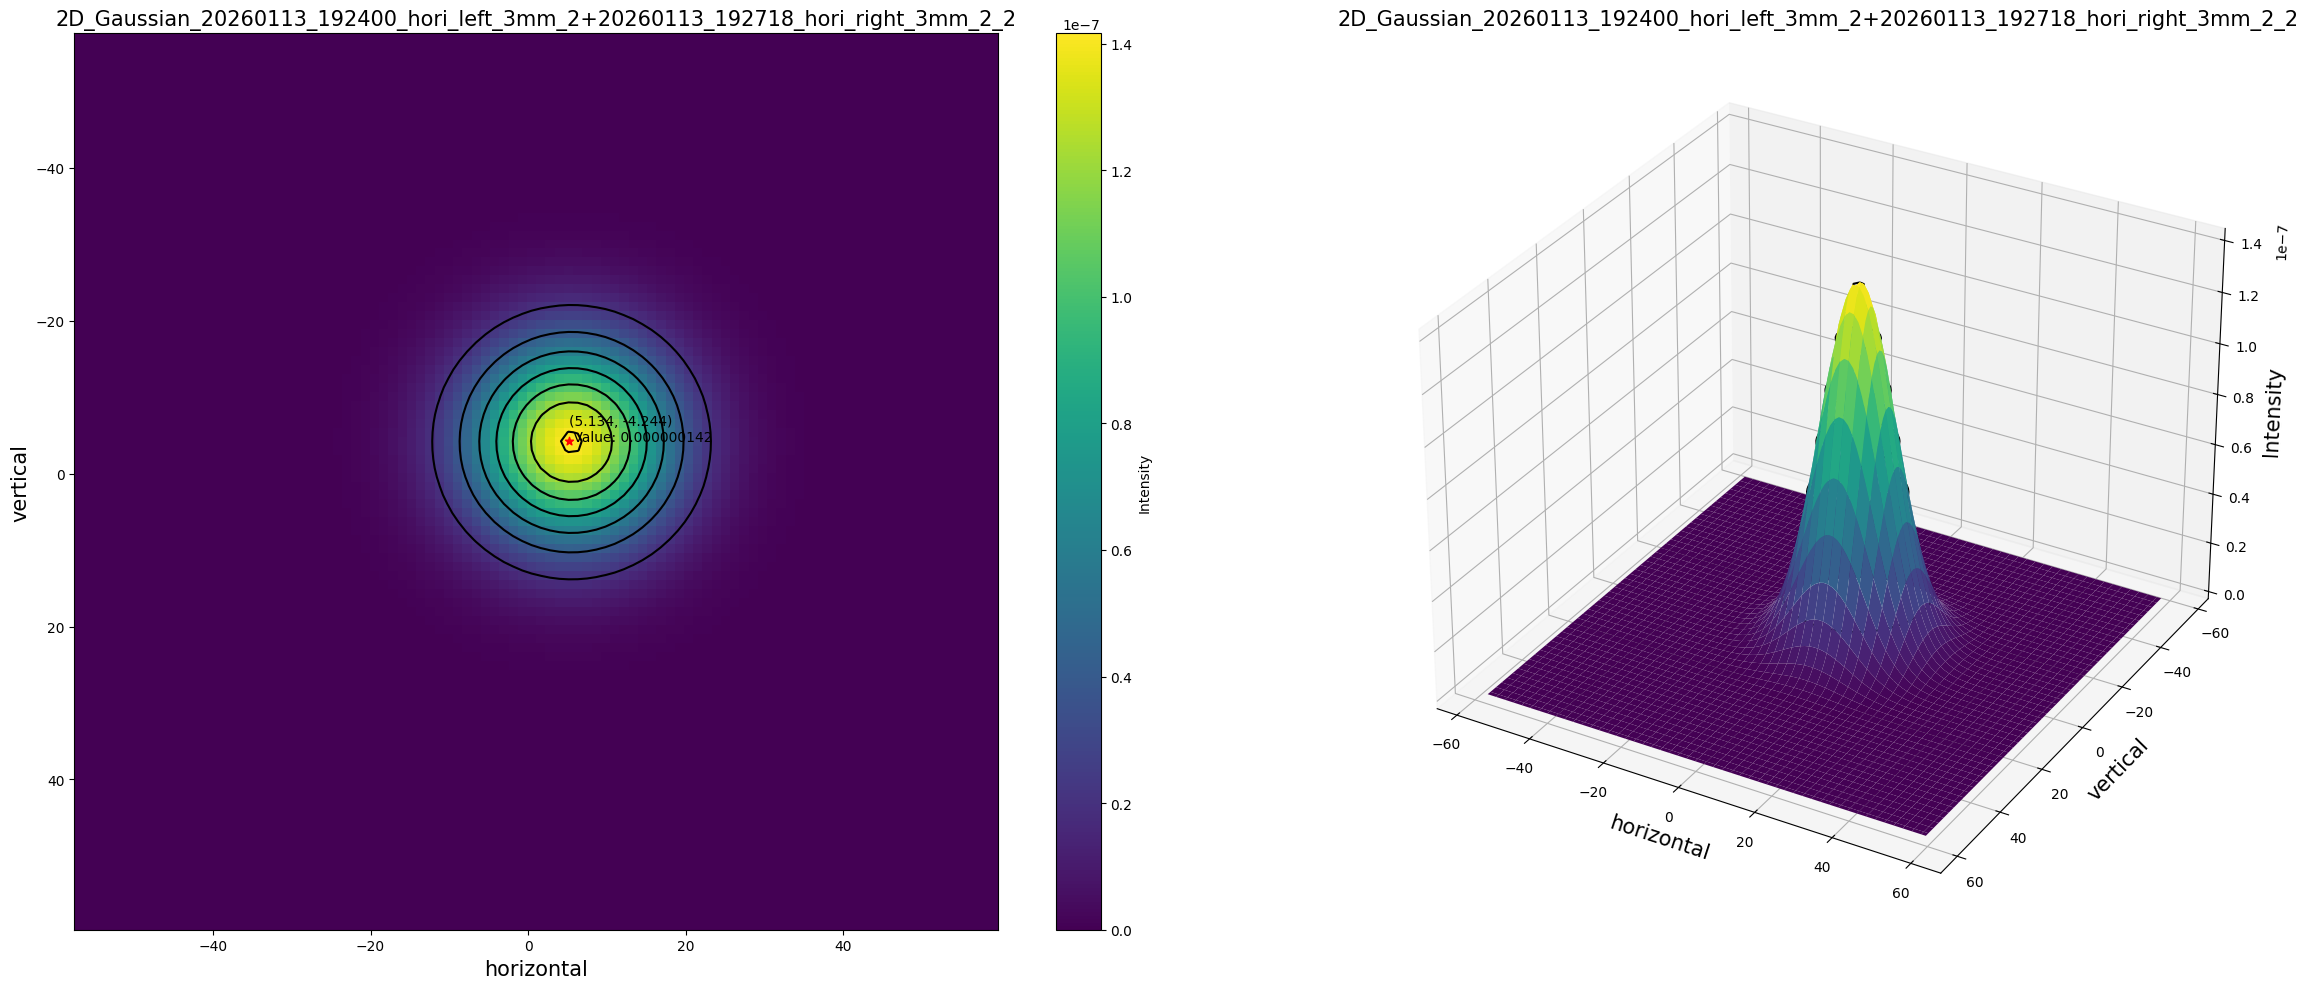

In [30]:
# 1次元ガウス関数の定義
def quadratic_func_gaus(posi, power, ave, sigma):
    return power*np.exp(-(((posi-ave)/sigma)**2)/2)

x_pos = x_hori
x_intensity = y_hori
y_pos = x_ver
y_intensity = y_ver

# それぞれの軸でフィッティング(近似パラメータの抽出)
# poptには[強度, 中心, 標準偏差]が入る
popt_x, pcov_x = curve_fit(quadratic_func_gaus, x_pos, x_intensity)
popt_y, pcov_y = curve_fit(quadratic_func_gaus, y_pos, y_intensity)

# 近似されたパラメータから滑らかな1次元分布を再生成
# データの個数を制限したり増やしたりする場合は、ここでnp.linspaceの数を調整する
x_smooth = quadratic_func_gaus(x_pos, popt_x[0], popt_x[1], popt_x[2])
y_smooth = quadratic_func_gaus(y_pos, popt_y[0], popt_y[1], popt_y[2])

# 外積(np.outer)を使って2次元分布を合成
# Z[i, j] = y_smooth[i]*x_smooth[j]となり、2次元の山ができる
Z = np.outer(x_smooth, y_smooth)

X, Y = np.meshgrid(x_pos, y_pos)
fig = plt.figure(figsize = (24, 10))

ax1 = fig.add_subplot(1, 2, 1)
cp = ax1.pcolormesh(X, Y, Z, shading = 'auto', cmap = 'viridis')
fig.colorbar(cp, ax = ax1, label = 'Intensity')
plt.contour(X, Y, Z, colors = ['black'])
ax1.invert_yaxis()
ax1.set_title('2D_Gaussian_' + basename_ver + '+' + basename_hori + '_2', fontsize = 15)
ax1.set_xlabel('horizontal', fontsize = 15)
ax1.set_ylabel('vertical', fontsize = 15)

max_power = np.argmax(Z) # 最大値を見つける
r_power, c_power = np.unravel_index(max_power, Z.shape) #　行と列のインデックスに変換する
max_hori = X[r_power, c_power] # 最大値の座標を見つける
max_ver = Y[r_power, c_power] # 最大値の座標を見つける
max_value = Z[r_power, c_power] # 最大値を取得する
ax1.scatter(max_hori, max_ver, color = 'red', marker = '*') # 最大値の座標を表示する
ax1.text(max_hori, max_ver, f'({max_hori:.3f}, {max_ver:.3f})\n Value: {max_value:.9f}')

ax2 = fig.add_subplot(1, 2, 2, projection = '3d')
ax2.plot_surface(X, Y, Z, cmap = 'viridis')
plt.contour(X, Y, Z, colors = ['black'])
ax2.invert_yaxis()
ax2.set_title('2D_Gaussian_' + basename_ver + '+' + basename_hori + '_2', fontsize = 15)
ax2.set_xlabel('horizontal', fontsize = 15)
ax2.set_ylabel('vertical', fontsize = 15)
ax2.set_zlabel('Intensity', fontsize = 15)

# plt.savefig(f'{basename_ver}+{basename_hori}_2d_gaussian_2.pdf', bbox_inches = 'tight', format = 'pdf', dpi = 100)
plt.tight_layout()
plt.subplots_adjust(right = 1, wspace = 0.01)
plt.show()

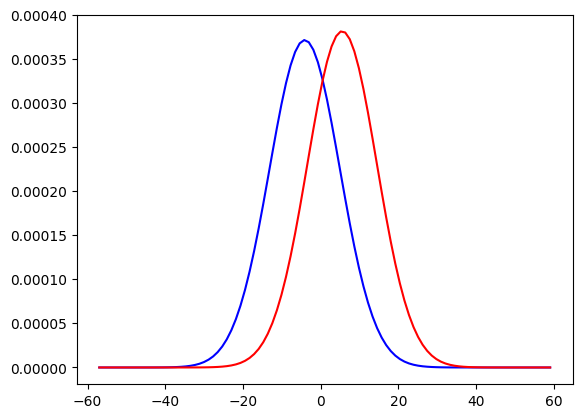

In [31]:
plt.plot(x_pos, x_intensity, color = 'blue')
plt.plot(y_pos, y_intensity, color = 'red')

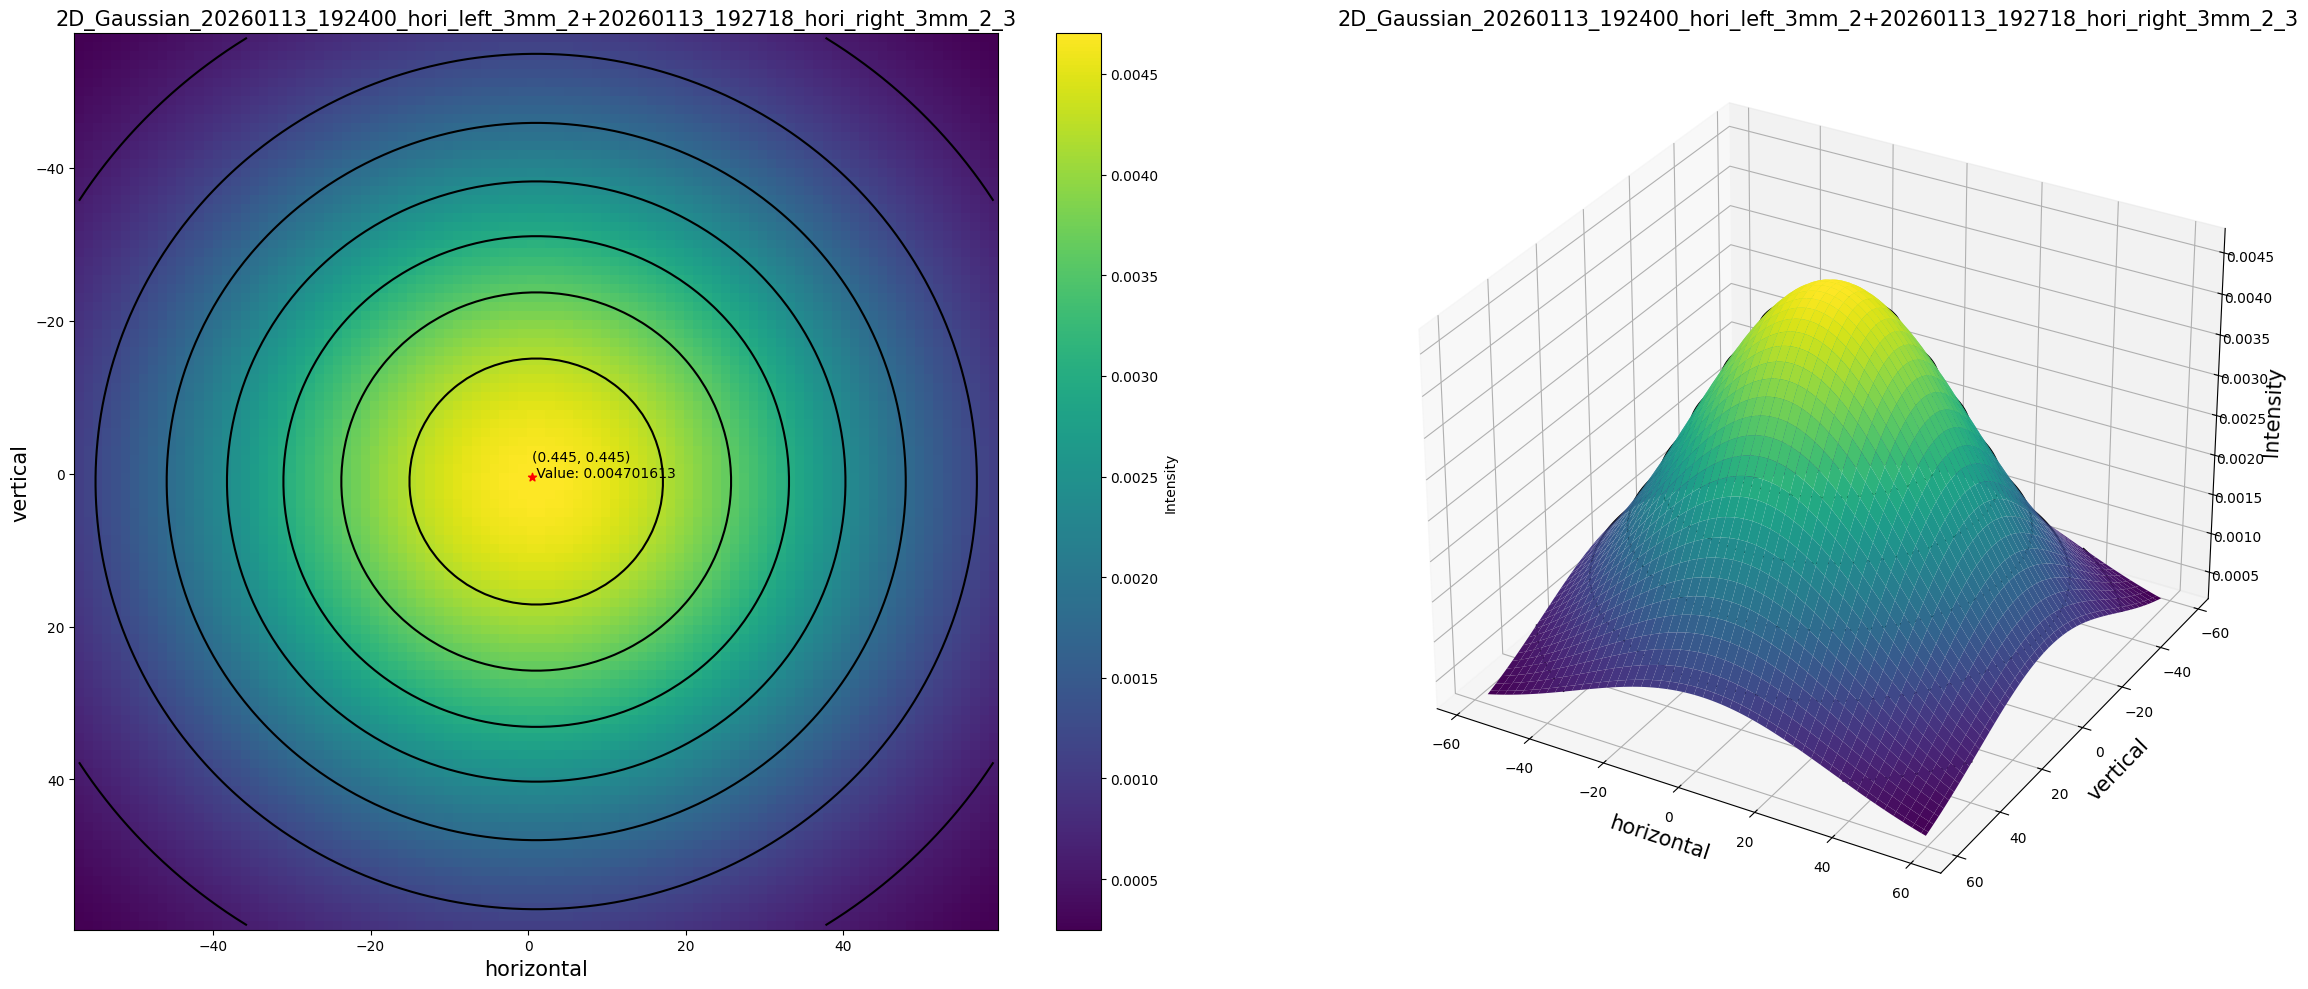

In [32]:
# パラメータ
# 平均(mu)と標準偏差(sigma)の計算
MU1, SIGMA1 = norm.fit(x_hori)
MU2, SIGMA2 = norm.fit(x_ver)

# (x1, x2)格子点を作成
x1_grid = x_hori
x2_grid = x_ver
X1, X2 = np.meshgrid(x1_grid, x2_grid)

# 同時分布関数(power*np.exp(-(((posi-ave)/sigma)**2)/2))
p1 = (np.exp(-(((X1-MU1)/SIGMA1)**2)/2))/np.sqrt(2*np.pi*SIGMA1)
p2 = (np.exp(-(((X2-MU2)/SIGMA2)**2)/2))/np.sqrt(2*np.pi*SIGMA2)
P = p1*p2

fig = plt.figure(figsize = (24, 10))

ax0 = fig.add_subplot(1, 2, 1)
cp = ax0.pcolormesh(X1, X2, P, cmap = 'viridis')
fig.colorbar(cp, ax = ax0, label = 'Intensity')
plt.contour(X1, X2, P, colors = ['black'])
ax0.invert_yaxis()
ax0.set_title('2D_Gaussian_' + basename_ver + '+' + basename_hori + '_3', fontsize = 15)
ax0.set_xlabel('horizontal', fontsize = 15)
ax0.set_ylabel('vertical', fontsize = 15)

max_power = np.argmax(P) # 最大値を見つける
r_power, c_power = np.unravel_index(max_power, P.shape) #　行と列のインデックスに変換する
max_hori = X1[r_power, c_power] # 最大値の座標を見つける
max_ver = X2[r_power, c_power] # 最大値の座標を見つける
max_value = P[r_power, c_power] # 最大値を取得する
ax0.scatter(max_hori, max_ver, color = 'red', marker = '*') # 最大値の座標を表示する
ax0.text(max_hori, max_ver, f'({max_hori:.3f}, {max_ver:.3f})\n Value: {max_value:.9f}')

ax1 = fig.add_subplot(1, 2, 2, projection = '3d')
ax1.plot_surface(X1, X2, P, cmap = 'viridis')
plt.contour(X1, X2, P, colors = ['black'])
ax1.invert_yaxis()
ax1.set_title('2D_Gaussian_' + basename_ver + '+' + basename_hori + '_3', fontsize = 15)
ax1.set_xlabel('horizontal', fontsize = 15)
ax1.set_ylabel('vertical', fontsize = 15)
ax1.set_zlabel('Intensity', fontsize = 15)

# plt.savefig(f'{basename_ver}+{basename_hori}_2d_gaussian_3.pdf', bbox_inches = 'tight', format = 'pdf', dpi = 100)
plt.tight_layout()
plt.subplots_adjust(right = 1, wspace = 0.01)
plt.show()

# 曲面をプロット
# fig = plt.figure(figsize = (24, 10))
# ax = fig.add_subplot(projection = "3d")
# ax.set_xlabel("x1", size = 15) # x1軸
# ax.set_ylabel("x2", size = 15) # x2軸
# ax.set_zlabel("P", size = 15) # p軸
# ax.plot_surface(X1, X2, P, cmap = "YlGn_r")
# plt.show()

# 等高線をプロット
# fig, ax = plt.subplots(figsize = (24, 10))
# plt.contour(X1, X2, P, cmap = "YlGn_r")
# ax.set_xlabel("x1", size = 15) # x1軸
# ax.set_ylabel("x2", size = 15) # x2軸
# plt.show()

In [33]:
print(MU1, SIGMA1, MU2, SIGMA2)
print(-(((X1-MU1)/SIGMA1)**2)/2, -(((X2-MU2)/SIGMA2)**2)/2)

1.0310621242485005 33.840983923682245 1.0310621242485005 33.840983923682245
[[-1.47029703 -1.41149115 -1.35388539 ... -1.35388539 -1.41149115
  -1.47029703]
 [-1.47029703 -1.41149115 -1.35388539 ... -1.35388539 -1.41149115
  -1.47029703]
 [-1.47029703 -1.41149115 -1.35388539 ... -1.35388539 -1.41149115
  -1.47029703]
 ...
 [-1.47029703 -1.41149115 -1.35388539 ... -1.35388539 -1.41149115
  -1.47029703]
 [-1.47029703 -1.41149115 -1.35388539 ... -1.35388539 -1.41149115
  -1.47029703]
 [-1.47029703 -1.41149115 -1.35388539 ... -1.35388539 -1.41149115
  -1.47029703]] [[-1.47029703 -1.47029703 -1.47029703 ... -1.47029703 -1.47029703
  -1.47029703]
 [-1.41149115 -1.41149115 -1.41149115 ... -1.41149115 -1.41149115
  -1.41149115]
 [-1.35388539 -1.35388539 -1.35388539 ... -1.35388539 -1.35388539
  -1.35388539]
 ...
 [-1.35388539 -1.35388539 -1.35388539 ... -1.35388539 -1.35388539
  -1.35388539]
 [-1.41149115 -1.41149115 -1.41149115 ... -1.41149115 -1.41149115
  -1.41149115]
 [-1.47029703 -1.47029